In [13]:
import numpy as np
import matplotlib.pyplot as polt
from sklearn import linear_model


In [14]:
# Длина зеленой волны ртути
lambda_green = 546.1 * 10**(-9)

In [ ]:
# Ширины щели
D_1 = 0.10 * 10**(-3) # у нс 0.15
D_2 = 0.15 * 10**(-3) # 0.20

# Расстояния между экраном и щелью
experiment_dists: dict[float, np.ndarray] = {
    D_1: np.array([2, 1.5, 1.0, 0.9, 0.7, 0.5]),
    D_2: np.array( [4.9, 3.8, 2.7, 2.0, 1.8, 1.5])
}


m_points = np.arange(1, 6 + 1)

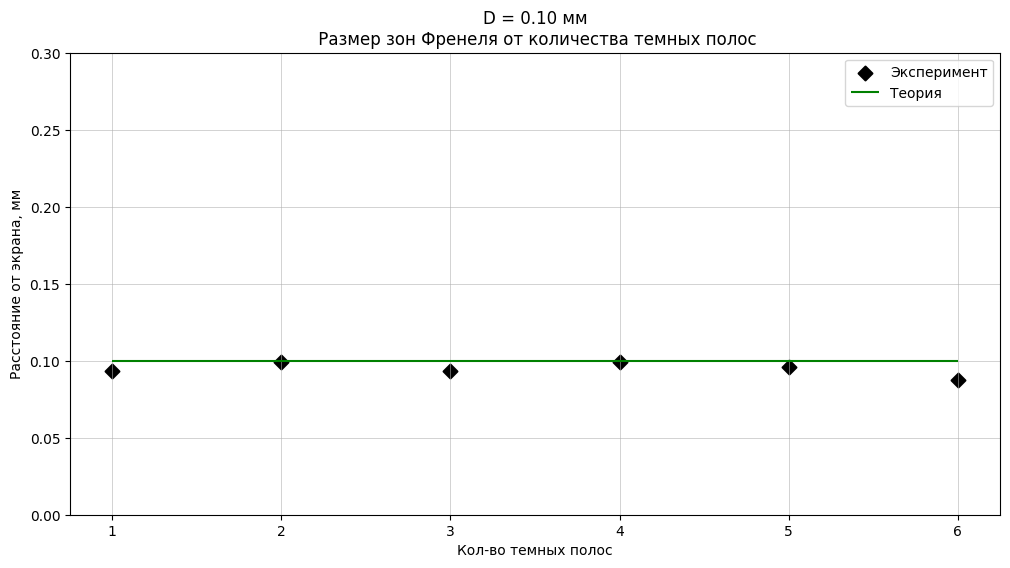

In [16]:
_, ax = polt.subplots(1, 1, figsize=(12, 6))

ax.set_title("D = 0.10 мм\n Размер зон Френеля от количества темных полос")
ax.set_xlabel("Кол-во темных полос")
ax.set_ylabel("Расстояние от экрана, мм")

ax.scatter(m_points,
           # можно взять 2*(2*experiment_dists[D_1], чтобы подогнать
           2 * (experiment_dists[D_1] * 10**(-3) * (m_points+1) * lambda_green)**0.5 * 10**3,
           s=50,
           linewidths=1.5,
           marker="D",
           color="black",
           label="Эксперимент")

ax.hlines(D_1 * 10**3,
          m_points[0],
          m_points[-1],
          color="green",
          label="Теория")


polt.ylim(0, 0.3)

polt.grid(which='minor', linestyle='--', linewidth=0.2)
polt.grid(which='major', linewidth=0.4)

polt.legend()
polt.show()

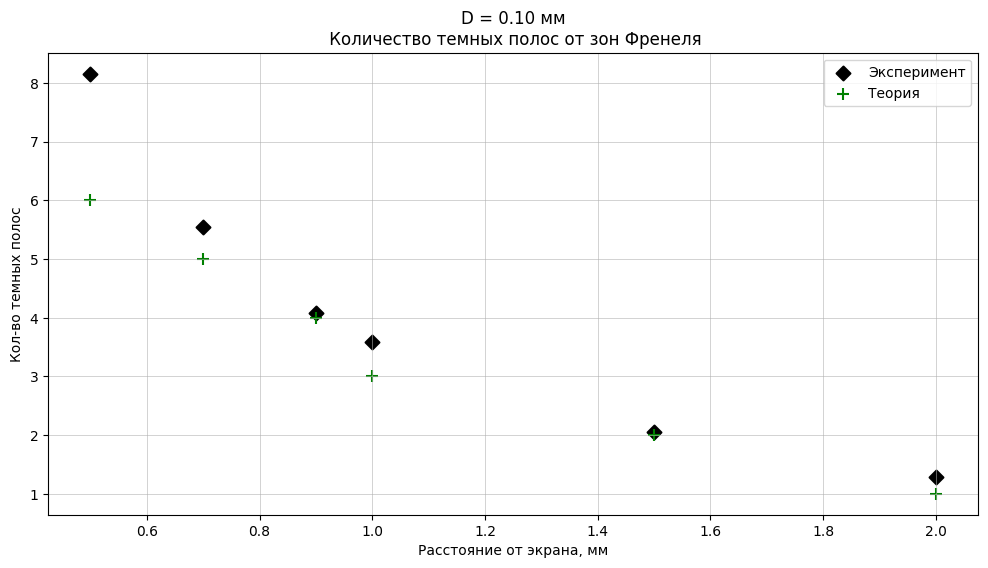

In [6]:
_, ax = polt.subplots(1, 1, figsize=(12, 6))

ax.set_title("D = 0.10 мм\n Количество темных полос от зон Френеля")
ax.set_xlabel("Расстояние от экрана, мм")
ax.set_ylabel("Кол-во темных полос")

ax.scatter(experiment_dists[D_1],
           # 2*4 * experiment_dists[D_1]- это подгоняний,
           # на самом деле, должно быть просто 4 (= 2**2) * experiment_dists[D_1]
           D_1**2 / (4 * experiment_dists[D_1] * 10**(-3) * lambda_green) - 1,
           s=50,
           linewidths=1.5,
           marker="D",
           color="black",
           label="Эксперимент")

ax.scatter(experiment_dists[D_1],
           m_points,
           s=75,
           marker="+",
           label="Теория",
           color="green")

polt.grid(which='minor', linestyle='--', linewidth=0.2)
polt.grid(which='major', linewidth=0.4)

polt.legend()
polt.show()

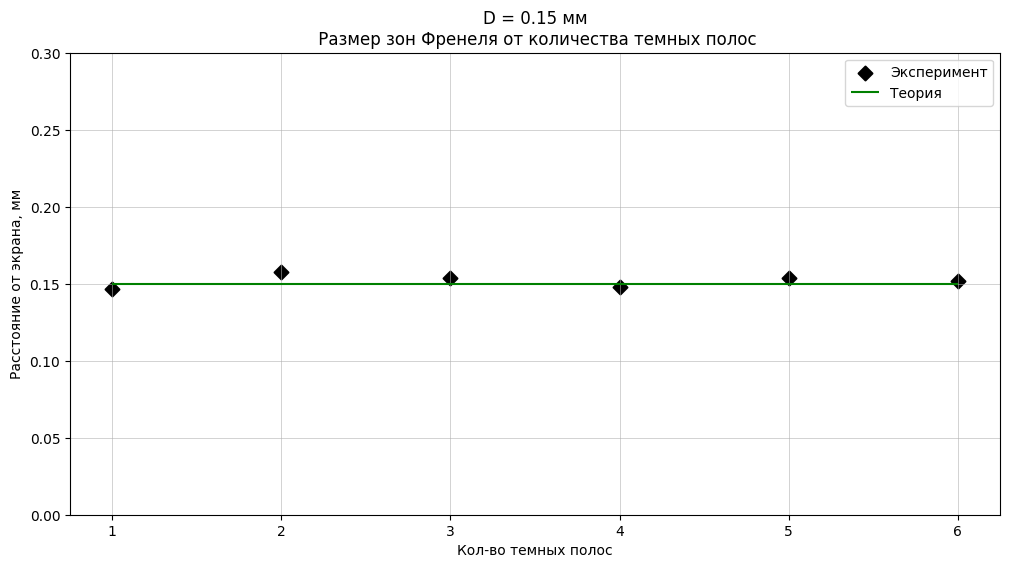

In [21]:
_, ax = polt.subplots(1, 1, figsize=(12, 6))

ax.set_title("D = 0.15 мм\n Размер зон Френеля от количества темных полос")
ax.set_xlabel("Кол-во темных полос")
ax.set_ylabel("Расстояние от экрана, мм")

ax.scatter(m_points,
           # можно взять 2*(2*experiment_dists[D_2], чтобы подогнать
           2 * (experiment_dists[D_2] * 10**(-3) * (m_points + 1) * lambda_green)**0.5 * 10**3,
           s=50,
           linewidths=1.5,
           marker="D",
           color="black",
           label="Эксперимент")

ax.hlines(D_2 * 10**3,
          m_points[0],
          m_points[-1],
          color="green",
          label="Теория")


polt.ylim(0, 0.3)

polt.grid(which='minor', linestyle='--', linewidth=0.2)
polt.grid(which='major', linewidth=0.4)

polt.legend()
polt.show()

In [21]:
# Ширины щелей
D_1 = 0.55 * 10**(-3)
D_2 = 0.60 * 10**(-3)  

# Минимумы, соотв. индексам: 0, 1, 2, 3
primary_experiment_mins: dict[float, np.ndarray] = {
    D_1: np.array([35.5, 35.7, 35.9, 36.0]) * 10**(-3),
    D_2: np.array([36.5, 36.6, 36.8, 36.9]) * 10**(-3)
}

# Фокусное расстояние второй линзы
f_2 = 0.17

# Минимумы, соотв. индексам: -3, -2, -1, 1, 2, 3
experiment_mins: dict[float, np.ndarray] = {}
for key, mins_0_1_2_3 in primary_experiment_mins.items():
  diffs = np.diff(mins_0_1_2_3)

  mins_minus_1_2_3 = [mins_0_1_2_3[0] - diffs[0],
                      mins_0_1_2_3[0] - diffs[0] - diffs[1],
                      mins_0_1_2_3[0] - diffs[0] - diffs[1] - diffs[2]]

  experiment_mins[key] = np.sort(np.concatenate((mins_minus_1_2_3, mins_0_1_2_3[1:])))


m_points = np.arange(-3, 3 + 1)
m_points = m_points[m_points != 0]


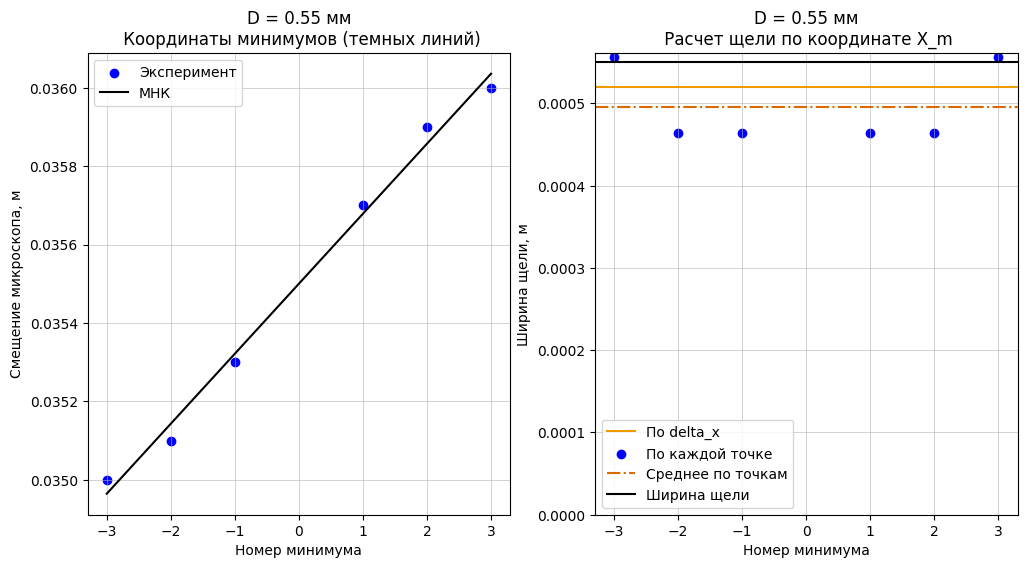

In [38]:
OLS = linear_model.LinearRegression()
OLS.fit(X=m_points.reshape(-1, 1), y=experiment_mins[D_1])

delta_x = OLS.coef_[-1]

#print(f"[bold] Δx =[/bold] {delta_x * 10**3:.5f} мм", border_style="white", title="[bold white]Коэффициент МНК[/bold white]")

_, (ax_1, ax_2) = polt.subplots(1, 2, figsize=(12, 6))

ax_1.set_title("D = 0.55 мм\n Координаты минимумов (темных линий)")
ax_1.set_xlabel("Номер минимума")
ax_1.set_ylabel("Смещение микроскопа, м")

ax_1.scatter(m_points,
             experiment_mins[D_1],
             color="blue",
             label="Эксперимент")

ax_1.plot(m_points,
          OLS.predict(m_points.reshape(-1, 1)),
          color="black",
          label="МНК")


ax_2.axhline(f_2 * lambda_green / delta_x,
             label="По delta_x",
             color="#EE9B01")

ax_2.scatter(m_points,
             f_2 * lambda_green * m_points /
             (experiment_mins[D_1] - experiment_mins[D_1].mean()),
             label="По каждой точке",
             color="blue")

ax_2.axhline((f_2 * lambda_green * m_points /
             (experiment_mins[D_1] - experiment_mins[D_1].mean())).mean(),
             linestyle='-.',
             label="Среднее по точкам",
             color="#DA6A00")

ax_2.axhline(D_1,
             label="Ширина щели",
             color="black")

ax_2.set_xlabel("Номер минимума")
ax_2.set_ylabel("Ширина щели, м")

ax_2.set_ylim(0)
ax_2.set_title("D = 0.55 мм\n Расчет щели по координате X_m")

for ax in (ax_1, ax_2):
#   ax.xaxis.set_major_locator(MultipleLocator(1))
#   ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#   ax.yaxis.set_minor_locator(AutoMinorLocator(10))

  ax.grid(which='minor', linestyle='--', linewidth=0.2)
  ax.grid(which='major', linewidth=0.4)
  ax.legend()

polt.show()

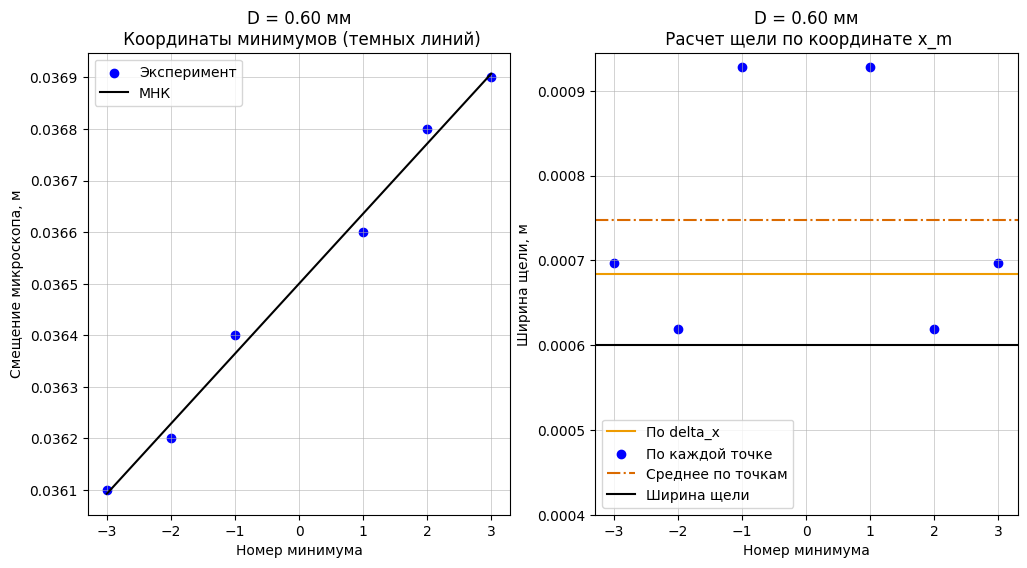

In [36]:

OLS = linear_model.LinearRegression()
OLS.fit(X=m_points.reshape(-1, 1), y=experiment_mins[D_2])

delta_x = OLS.coef_[-1]

_, (ax_1, ax_2) = polt.subplots(1, 2, figsize=(12, 6))

ax_1.set_title("D = 0.60 мм\n Координаты минимумов (темных линий)")
ax_1.set_xlabel("Номер минимума")
ax_1.set_ylabel("Смещение микроскопа, м")

ax_1.scatter(m_points,
             experiment_mins[D_2],
             color="blue",
             label="Эксперимент")

ax_1.plot(m_points,
          OLS.predict(m_points.reshape(-1, 1)),
          color="black",
          label="МНК")


ax_2.axhline(f_2 * lambda_green / delta_x,
             label="По delta_x",
             color="#EE9B01")

ax_2.scatter(m_points,
             f_2 * lambda_green * m_points /
             (experiment_mins[D_2] - experiment_mins[D_2].mean()),
             label="По каждой точке",
             color="blue")

ax_2.axhline((f_2 * lambda_green * m_points /
              (experiment_mins[D_2] - experiment_mins[D_2].mean())).mean(),
             linestyle='-.',
             label="Среднее по точкам",
             color="#DA6A00")

ax_2.axhline(D_2,
             label="Ширина щели",
             color="black")

ax_2.set_xlabel("Номер минимума")
ax_2.set_ylabel("Ширина щели, м")

ax_2.set_ylim(0.0004)
ax_2.set_title("D = 0.60 мм\n Расчет щели по координате x_m")

for ax in (ax_1, ax_2):
#   ax.xaxis.set_major_locator(MultipleLocator(1))
#   ax.xaxis.set_minor_locator(AutoMinorLocator(10))
#   ax.yaxis.set_minor_locator(AutoMinorLocator(10))

  ax.grid(which='minor', linestyle='--', linewidth=0.2)
  ax.grid(which='major', linewidth=0.4)
  ax.legend()

polt.show()

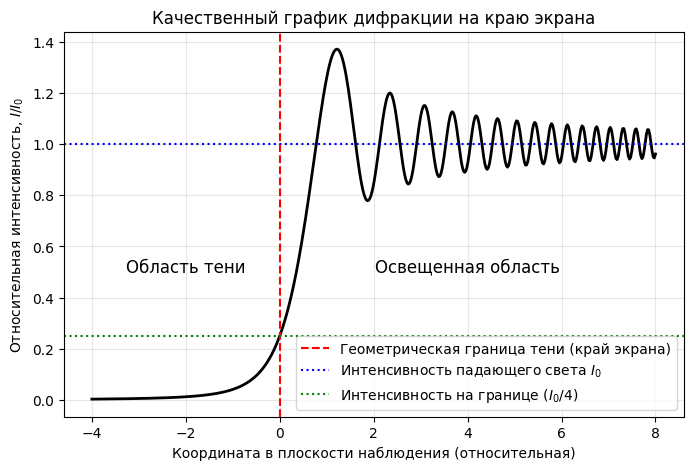

In [35]:
import matplotlib.pyplot as plt
from scipy.special import fresnel
#РАСПРЕДЕЛЕНИЕ Генерация качественного графика дифракции на краю экрана
# Используем интегралы Френеля из scipy
v = np.linspace(-4, 8, 500)
S, C = fresnel(v)

# Интенсивность (нормализованная, I_0 = 1)
# I = 0.5 * ((C(v) + 0.5)^2 + (S(v) + 0.5)^2) * I_0
I = 0.5 * ((C + 0.5)**2 + (S + 0.5)**2)

plt.figure(figsize=(8, 5))
plt.plot(v, I, 'k-', linewidth=2)

# Оформление качественного графика
plt.axvline(0, color='r', linestyle='--', label='Геометрическая граница тени (край экрана)')
plt.axhline(1, color='b', linestyle=':', label='Интенсивность падающего света $I_0$')
plt.axhline(0.25, color='g', linestyle=':', label='Интенсивность на границе ($I_0/4$)')

plt.title('Качественный график дифракции на краю экрана')
plt.xlabel('Координата в плоскости наблюдения (относительная)')
plt.ylabel('Относительная интенсивность, $I/I_0$')
plt.text(-2, 0.5, 'Область тени', fontsize=12, ha='center')
plt.text(4, 0.5, 'Освещенная область', fontsize=12, ha='center')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()